# QM640 Food Price Affordability AI
## Notebook 04 — Synopsis-Aligned Statistical Analysis

**Research question RQ1:** Which lagged-price, market-arrival, climatic,
seasonal, agricultural-production, and macroeconomic variables significantly
influence one- to three-month essential-food price changes in India?

This notebook tests exact 1-, 2-, and 3-month outcomes using state and commodity
fixed effects, calendar-month controls, and state-clustered standard errors.
The available-variable hypothesis contains more than four predictors. Genuine
market arrivals remain missing and are never replaced by reporting counts.


## 1. Colab setup and verified inputs


In [1]:
from pathlib import Path
import json, os, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/QM640_Food_Affordability")
else:
    root = Path.cwd().resolve()
    if root.name == "notebooks":
        root = root.parent
    OUTPUT_ROOT = Path(os.environ.get("QM640_OUTPUT_ROOT", str(root)))

PROCESSED = OUTPUT_ROOT / "data" / "processed"
REPORT_OUTPUT = OUTPUT_ROOT / "reports" / "notebook_outputs"
FIGURES = REPORT_OUTPUT / "figures"
REPORT_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SKIP_PLOTS = os.environ.get("QM640_SKIP_PLOTS", "0") == "1"

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
if not SKIP_PLOTS:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

STATE_FILE = PROCESSED / "cleaned_state_monthly.csv.gz"
NB02_FILE = REPORT_OUTPUT / "02_execution_summary.json"
NB03_FILE = REPORT_OUTPUT / "03_execution_summary.json"
for required in [STATE_FILE, NB02_FILE, NB03_FILE]:
    if not required.exists():
        raise FileNotFoundError(f"Run the preceding aligned notebooks first: {required}")

state = pd.read_csv(
    STATE_FILE, parse_dates=["date"],
    dtype={"region": "category", "Commodity": "category"}, low_memory=False
)
nb02 = json.loads(NB02_FILE.read_text(encoding="utf-8"))
nb03 = json.loads(NB03_FILE.read_text(encoding="utf-8"))
assert len(state) == nb02["clean_state_rows"]
print(f"Verified state rows: {len(state):,}")
print("Confirmatory status:", nb02["confirmatory_source_status"])


Mounted at /content/drive
Verified state rows: 41,792
Confirmatory status: {'market_arrivals': 'missing', 'state_crop_apy': 'integrated', 'rural_wages': 'integrated_partial_coverage', 'hces_microdata': 'available_aggregate_for_notebook_08'}


## 2. Analysis variables and safeguards


In [2]:
TARGETS = {
    1: "future_price_change_h1m_pct",
    2: "future_price_change_h2m_pct",
    3: "future_price_change_h3m_pct",
}
CORE_VARIABLES = [
    "price_mom_pct",
    "price_yoy_pct",
    "rainfall_anomaly_pct",
    "temperature_anomaly_c",
    "relative_humidity_pct",
]
APY_VARIABLES = ["production_tonne", "yield_kg_per_hectare"]
CONTROL_VARIABLES = ["source_rows"]  # reporting coverage only; not market arrivals
WAGE_VARIABLES = ["rural_wage_rs_per_day"]

required_columns = list(TARGETS.values()) + CORE_VARIABLES + APY_VARIABLES + CONTROL_VARIABLES
missing = [column for column in required_columns if column not in state.columns]
if missing:
    raise KeyError("Notebook 02 outputs are missing required columns: " + ", ".join(missing))

analysis = state.copy()
analysis["month"] = analysis["date"].dt.month.astype("category")
analysis["log_production"] = np.log1p(pd.to_numeric(analysis["production_tonne"], errors="coerce"))
analysis["log_yield"] = np.log1p(pd.to_numeric(analysis["yield_kg_per_hectare"], errors="coerce"))
analysis["log_reporting_coverage"] = np.log1p(pd.to_numeric(analysis["source_rows"], errors="coerce"))

MODEL_FEATURES = [
    "price_mom_pct",
    "price_yoy_pct",
    "rainfall_anomaly_pct",
    "temperature_anomaly_c",
    "relative_humidity_pct",
    "log_production",
    "log_yield",
    "log_reporting_coverage",
]
for feature in MODEL_FEATURES:
    values = pd.to_numeric(analysis[feature], errors="coerce")
    sd = values.std()
    analysis[f"{feature}_z"] = (values - values.mean()) / sd if sd and np.isfinite(sd) else np.nan

MODEL_Z = [f"{feature}_z" for feature in MODEL_FEATURES]
print("Available-variable hypothesis predictors:")
print("\n".join(f"- {feature}" for feature in MODEL_FEATURES))
print("\nSafeguard: log_reporting_coverage is a control, not market arrivals.")


Available-variable hypothesis predictors:
- price_mom_pct
- price_yoy_pct
- rainfall_anomaly_pct
- temperature_anomaly_c
- relative_humidity_pct
- log_production
- log_yield
- log_reporting_coverage

Safeguard: log_reporting_coverage is a control, not market arrivals.


## 3. Fixed-effects models for exact 1-, 2-, and 3-month outcomes


In [3]:
model_rows, coefficient_rows, joint_rows = [], [], []
fitted_models = {}

for horizon, target in TARGETS.items():
    columns = [target, "region", "Commodity", "month", *MODEL_Z]
    sample = analysis[columns].dropna().copy()
    # Winsorisation is model-only and limits extreme leverage; raw targets remain preserved.
    lower, upper = sample[target].quantile([0.01, 0.99])
    sample["target_model"] = sample[target].clip(lower, upper)
    formula = (
        "target_model ~ " + " + ".join(MODEL_Z)
        + " + C(region) + C(Commodity) + C(month)"
    )
    result = smf.ols(formula, data=sample).fit(
        cov_type="cluster", cov_kwds={"groups": sample["region"]}
    )
    fitted_models[horizon] = result
    residual_rmse = float(np.sqrt(np.mean(np.square(result.resid))))
    model_rows.append({
        "horizon_months": horizon,
        "n": int(result.nobs),
        "states_uts": int(sample["region"].nunique()),
        "commodities": int(sample["Commodity"].nunique()),
        "r_squared": float(result.rsquared),
        "adjusted_r_squared": float(result.rsquared_adj),
        "residual_rmse_pct": residual_rmse,
        "target_winsor_lower_pct": float(lower),
        "target_winsor_upper_pct": float(upper),
        "covariance": "state-clustered",
    })
    for feature in MODEL_Z:
        coefficient_rows.append({
            "horizon_months": horizon,
            "term": feature,
            "coefficient": float(result.params[feature]),
            "std_error": float(result.bse[feature]),
            "p_value": float(result.pvalues[feature]),
        })
    # Joint Wald test of all available driver coefficients.
    param_names = list(result.params.index)
    restriction = np.zeros((len(MODEL_Z), len(param_names)))
    for row, feature in enumerate(MODEL_Z):
        restriction[row, param_names.index(feature)] = 1
    test = result.wald_test(restriction, scalar=True)
    joint_rows.append({
        "horizon_months": horizon,
        "null_hypothesis": "all available driver coefficients jointly equal zero",
        "wald_statistic": float(np.asarray(test.statistic).squeeze()),
        "degrees_of_freedom": int(len(MODEL_Z)),
        "p_value": float(np.asarray(test.pvalue).squeeze()),
        "decision_at_5pct": "reject_available_variable_H0" if float(test.pvalue) < 0.05 else "fail_to_reject_available_variable_H0",
        "full_original_H0_status": "not_fully_adjudicated_market_arrivals_missing",
    })

model_metrics = pd.DataFrame(model_rows)
coefficients = pd.DataFrame(coefficient_rows)
joint_tests = pd.DataFrame(joint_rows)

# Benjamini-Hochberg controls the false-discovery rate across 24 focal tests.
coefficients["p_value_bh"] = multipletests(
    coefficients["p_value"], alpha=0.05, method="fdr_bh"
)[1]
coefficients["significant_bh_5pct"] = coefficients["p_value_bh"].lt(0.05)

model_metrics.to_csv(REPORT_OUTPUT / "04_horizon_model_metrics.csv", index=False)
coefficients.to_csv(REPORT_OUTPUT / "04_horizon_coefficients.csv", index=False)
joint_tests.to_csv(REPORT_OUTPUT / "04_joint_hypothesis_tests.csv", index=False)
print(model_metrics.round(4).to_string(index=False))
print("\nJoint RQ1 hypothesis tests")
print(joint_tests.round(6).to_string(index=False))
print("\nBH-adjusted focal coefficients")
print(coefficients.round(5).to_string(index=False))


 horizon_months    n  states_uts  commodities  r_squared  adjusted_r_squared  residual_rmse_pct  target_winsor_lower_pct  target_winsor_upper_pct      covariance
              1 3798          25            6     0.2474              0.2377            16.3514                 -42.8782                  68.6605 state-clustered
              2 3783          25            6     0.2494              0.2398            28.0714                 -58.8479                 123.1951 state-clustered
              3 3777          25            6     0.2659              0.2564            37.4759                 -67.2578                 177.2908 state-clustered

Joint RQ1 hypothesis tests
 horizon_months                                      null_hypothesis  wald_statistic  degrees_of_freedom  p_value             decision_at_5pct                       full_original_H0_status
              1 all available driver coefficients jointly equal zero      712.562772                   8      0.0 reject_available_vari

## 4. Partial-wage supplementary analysis


In [4]:
wage_rows = []
if "rural_wage_rs_per_day" in analysis.columns:
    wage_values = pd.to_numeric(analysis["rural_wage_rs_per_day"], errors="coerce")
    if wage_values.notna().sum() >= 100:
        analysis["rural_wage_level_z"] = (
            wage_values - wage_values.mean()
        ) / wage_values.std()
        for horizon, target in TARGETS.items():
            cols = [target, "region", "Commodity", "month", "rural_wage_level_z", *MODEL_Z[:5]]
            sample = analysis[cols].dropna().copy()
            if len(sample) < 100 or sample["region"].nunique() < 5:
                continue
            lo, hi = sample[target].quantile([0.01, 0.99])
            sample["target_model"] = sample[target].clip(lo, hi)
            formula = (
                "target_model ~ rural_wage_level_z + "
                + " + ".join(MODEL_Z[:5])
                + " + C(region) + C(Commodity) + C(month)"
            )
            result = smf.ols(formula, data=sample).fit(
                cov_type="cluster", cov_kwds={"groups": sample["region"]}
            )
            wage_rows.append({
                "horizon_months": horizon,
                "n": int(result.nobs),
                "states_uts": int(sample["region"].nunique()),
                "coefficient": float(result.params["rural_wage_level_z"]),
                "std_error": float(result.bse["rural_wage_level_z"]),
                "p_value": float(result.pvalues["rural_wage_level_z"]),
                "coverage_warning": "FY2025-26 partial export; supplementary only",
            })
wage_results = pd.DataFrame(wage_rows)
wage_results.to_csv(REPORT_OUTPUT / "04_partial_wage_supplement.csv", index=False)
print(wage_results.round(5).to_string(index=False) if len(wage_results) else "No adequate wage subsample.")


 horizon_months   n  states_uts  coefficient  std_error  p_value                             coverage_warning
              1 703          25      1.20035    0.53937  0.02605 FY2025-26 partial export; supplementary only
              2 700          25      0.73985    1.51617  0.62557 FY2025-26 partial export; supplementary only
              3 697          25      0.92241    2.51673  0.71398 FY2025-26 partial export; supplementary only


## 5. Visual comparison


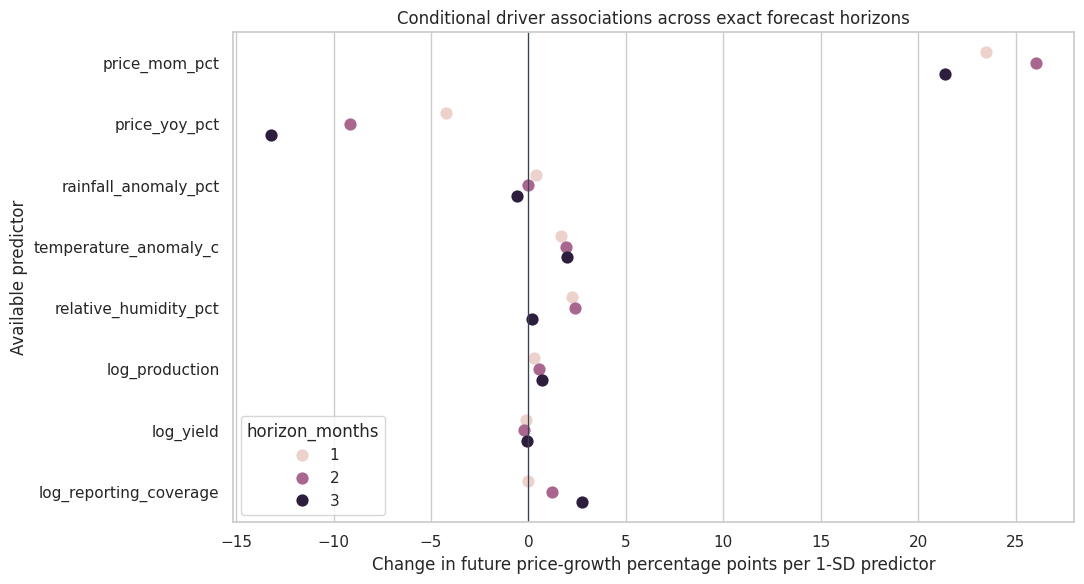

In [5]:
if not SKIP_PLOTS:
    plot = coefficients.copy()
    plot["label"] = plot["term"].str.replace("_z", "", regex=False)
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.pointplot(
        data=plot, x="coefficient", y="label", hue="horizon_months",
        dodge=0.35, linestyles="", markers="o", ax=ax
    )
    ax.axvline(0, color="#374151", linewidth=0.9)
    ax.set(
        title="Conditional driver associations across exact forecast horizons",
        xlabel="Change in future price-growth percentage points per 1-SD predictor",
        ylabel="Available predictor",
    )
    fig.tight_layout()
    fig.savefig(FIGURES / "04_horizon_driver_coefficients.png", bbox_inches="tight")
    plt.show()


## 6. Execution summary and interpretation


In [6]:
significant = coefficients.loc[coefficients["significant_bh_5pct"]].copy()
summary = {
    "notebook": "04_statistical_analysis_synopsis_aligned",
    "status": "completed",
    "original_research_question_preserved": True,
    "research_question": (
        "Which lagged-price, market-arrival, climatic, seasonal, agricultural-production, "
        "and macroeconomic variables significantly influence one- to three-month "
        "essential-food price changes in India?"
    ),
    "dependent_variable_horizons_months": [1, 2, 3],
    "available_model_predictors": MODEL_FEATURES,
    "predictor_count": len(MODEL_FEATURES),
    "models": {
        f"{int(row.horizon_months)}_month": {
            "n": int(row.n),
            "states_uts": int(row.states_uts),
            "r_squared": float(row.r_squared),
            "adjusted_r_squared": float(row.adjusted_r_squared),
            "residual_rmse_pct": float(row.residual_rmse_pct),
        }
        for row in model_metrics.itertuples()
    },
    "joint_test_decisions": {
        f"{int(row.horizon_months)}_month": row.decision_at_5pct
        for row in joint_tests.itertuples()
    },
    "bh_significant_available_terms": [
        {
            "horizon_months": int(row.horizon_months),
            "term": row.term,
            "coefficient": float(row.coefficient),
            "p_value_bh": float(row.p_value_bh),
        }
        for row in significant.itertuples()
    ],
    "partial_wage_models": int(len(wage_results)),
    "market_arrivals_status": nb02["confirmatory_source_status"].get("market_arrivals", "missing"),
    "full_original_h0_status": "not fully adjudicated because genuine market arrivals are missing",
    "multiple_testing_control": "Benjamini-Hochberg FDR at 5%",
    "inference_warning": "Conditional associations; not causal effects.",
    "output_root": str(OUTPUT_ROOT),
}
SUMMARY_FILE = REPORT_OUTPUT / "04_execution_summary.json"
SUMMARY_FILE.write_text(json.dumps(summary, indent=2), encoding="utf-8")

expected = [
    REPORT_OUTPUT / "04_horizon_model_metrics.csv",
    REPORT_OUTPUT / "04_horizon_coefficients.csv",
    REPORT_OUTPUT / "04_joint_hypothesis_tests.csv",
    REPORT_OUTPUT / "04_partial_wage_supplement.csv",
    SUMMARY_FILE,
]
if not SKIP_PLOTS:
    expected.append(FIGURES / "04_horizon_driver_coefficients.png")
missing = [str(path) for path in expected if not path.exists()]
if missing:
    raise FileNotFoundError("Missing Notebook 04 artifacts:\n" + "\n".join(missing))

print("=" * 76)
print("NOTEBOOK 04 ALIGNED EXECUTION SUMMARY ")
print("=" * 76)
print(json.dumps(summary, indent=2))
print(f"\nVerified artifacts: {len(expected)}")


NOTEBOOK 04 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT
{
  "notebook": "04_statistical_analysis_synopsis_aligned",
  "status": "completed",
  "original_research_question_preserved": true,
  "research_question": "Which lagged-price, market-arrival, climatic, seasonal, agricultural-production, and macroeconomic variables significantly influence one- to three-month essential-food price changes in India?",
  "dependent_variable_horizons_months": [
    1,
    2,
    3
  ],
  "available_model_predictors": [
    "price_mom_pct",
    "price_yoy_pct",
    "rainfall_anomaly_pct",
    "temperature_anomaly_c",
    "relative_humidity_pct",
    "log_production",
    "log_yield",
    "log_reporting_coverage"
  ],
  "predictor_count": 8,
  "models": {
    "1_month": {
      "n": 3798,
      "states_uts": 25,
      "r_squared": 0.24736534295624102,
      "adjusted_r_squared": 0.23772904966787067,
      "residual_rmse_pct": 16.351368267303535
    },
    "2_month": {
      "n": 3783,
      "sta

## Notebook 04 conclusion

The joint tests evaluate H0-1 for the available price, climate, production,
yield, humidity, seasonality, and reporting-coverage variables. Results are
conditional associations, not causal effects. Because genuine market-arrival
quantity is still missing, the complete original H0-1 is explicitly left
partially unresolved rather than silently redefined.
